> **Simulated data.** Everything below is generated from a data-generating
> process written out in the notebook, so the true treatment effect is known
> exactly. Nothing here is an empirical result about any real country or
> programme; it is a check on how an estimator behaves when we already know the
> answer.

Most of the treatments a development economist studies arrive **in waves**.
Submarine fibre-optic cables landed in Kenya in 2009, in Nigeria in 2010, in
Cameroon in 2012. Mobile money launched country by country. Cash-transfer
programmes roll out district by district.

The reflex is to put everything into one regression with unit and time fixed
effects:

$$y_{it} = \alpha_i + \lambda_t + \beta\,D_{it} + \varepsilon_{it}$$

where $D_{it}=1$ once unit $i$ has been treated. That single $\beta$ is
convenient to report. Under staggered adoption with an effect that grows over
time, it is also **not** the average effect on the treated.

The reason is a comparison the regression makes on your behalf. Units treated
*earlier* end up serving as controls for units treated *later*. If the effect
keeps growing, those early units are still improving when they are used as a
counterfactual, so the comparison nets part of the treatment effect out against
itself ([Goodman-Bacon,
2021](https://doi.org/10.1016/j.jeconom.2021.03.014); [de Chaisemartin and
D'Haultfœuille, 2020](https://doi.org/10.1257/aer.20181169)).

That argument is easy to state and easy to nod along to. What follows puts a
number on it, and then isolates the offending comparison so you can see it on
its own.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Site palette, so the figures match the rest of the pages.
NAVY, GOLD, GREY = "#003262", "#b8862c", "#8a8f98"

plt.rcParams.update({
    "figure.figsize": (7.6, 4.2),
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c9c4b8",
    "axes.labelcolor": "#191c20",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": "#191c20",
    "xtick.color": "#565e68",
    "ytick.color": "#565e68",
    "font.size": 10,
    "grid.color": "#e8e4da",
    "legend.frameon": False,
})

rng = np.random.default_rng(20260728)


## A rollout in two waves

1,200 districts observed over 20 years. Four hundred are connected in year 6,
four hundred in year 12, and four hundred never. The effect of connection is
**identical for the two cohorts**: it builds up over eight years and then
plateaus at 0.30. Making it identical matters, because it means whatever bias
appears below cannot be blamed on the cohorts differing from one another. It
comes purely from the effect taking time to arrive.

Trends are parallel by construction and there is no anticipation.


In [2]:
N_PER_COHORT, T = 400, 20
COHORTS = [6, 12, 0]      # 0 marks the never-connected districts
LONG_RUN = 0.30           # plateau of the effect, the same for both cohorts
RAMP = 8                  # years needed to reach the plateau

def effect(cohort, year):
    '''True effect of connection for a district of `cohort` in `year`.'''
    if cohort == 0 or year < cohort:
        return 0.0
    exposure = min(year - cohort, RAMP)
    return LONG_RUN * (exposure + 1) / (RAMP + 1)

rows, unit = [], 0
for cohort in COHORTS:
    for _ in range(N_PER_COHORT):
        district = rng.normal(0, 0.5)                    # district fixed effect
        for year in range(T):
            common = 0.02 * year                         # shared time trend
            tau = effect(cohort, year)
            y = district + common + tau + rng.normal(0, 0.15)
            rows.append((unit, year, cohort,
                         int(cohort != 0 and year >= cohort), tau, y))
        unit += 1

panel = pd.DataFrame(
    rows, columns=["unit", "year", "cohort", "treated", "true_effect", "y"]
)
panel.head()


,unit,year,cohort,treated,true_effect,y
0,0,0,6,0,0.0,0.939823
1,0,1,6,0,0.0,0.927909
2,0,2,6,0,0.0,1.126536
3,0,3,6,0,0.0,1.029865
4,0,4,6,0,0.0,1.081767


In [3]:
treated_rows = panel.query("treated == 1")
true_att = treated_rows["true_effect"].mean()

print(f"Districts             : {panel['unit'].nunique():,}")
print(f"Observations          : {len(panel):,}")
print(f"Treated observations  : {len(treated_rows):,}")
print(f"True ATT (the target) : {true_att:.4f}")


Districts             : 1,200
Observations          : 24,000
Treated observations  : 8,800
True ATT (the target) : 0.1909


The true average effect on the treated is the mean of `true_effect` over every
treated district-year. It comes out near 0.19 rather than 0.30, because most
treated observations are still climbing the ramp rather than sitting at the
plateau. That is the number an estimator should recover.


## What the standard regression reports

Ordinary least squares on district dummies, year dummies, and the treatment
indicator.


In [4]:
def twfe(df, treat_cols):
    '''OLS of y on district dummies, year dummies and `treat_cols`.
    Returns the coefficients on `treat_cols`.'''
    unit_d = pd.get_dummies(df["unit"], prefix="u", drop_first=True, dtype=float)
    year_d = pd.get_dummies(df["year"], prefix="t", drop_first=True, dtype=float)
    X = pd.concat([df[treat_cols].astype(float), unit_d, year_d], axis=1)
    X.insert(0, "const", 1.0)
    coefs, *_ = np.linalg.lstsq(X.to_numpy(), df["y"].to_numpy(), rcond=None)
    return pd.Series(coefs[1:1 + len(treat_cols)], index=treat_cols)

beta = twfe(panel, ["treated"]).iloc[0]

print(f"True ATT      : {true_att: .4f}")
print(f"TWFE estimate : {beta: .4f}")
print(f"Gap           : {beta - true_att: .4f}   "
      f"({100 * (beta - true_att) / true_att:+.1f}%)")


True ATT      :  0.1909
TWFE estimate :  0.1336
Gap           : -0.0573   (-30.0%)


Thirty percent low, on 24,000 observations, with no measurement error, no
omitted variable, and parallel trends holding exactly. Sampling noise is not the
explanation. The estimator is answering a different question from the one asked.


## Isolating the comparison that breaks

A staggered design contains several two-by-two difference-in-differences
comparisons, and the regression above is a weighted average of all of them. Two
of them matter for the districts connected in year 12:

- **Clean.** Against districts that are *never* connected.
- **Forbidden.** Against the year-6 cohort — districts connected six years
  earlier, whose own effect is still growing.

Both are computed below from the same data, anchored to year 11, the last year
before the second wave arrives.


In [5]:
wide = panel.pivot_table(index="unit", columns="year", values="y")
cohort_of = panel.groupby("unit")["cohort"].first()

def did(treated_units, control_units, base_year, year):
    '''Two-period, two-group difference-in-differences.'''
    d_treated = (wide.loc[treated_units, year].mean()
                 - wide.loc[treated_units, base_year].mean())
    d_control = (wide.loc[control_units, year].mean()
                 - wide.loc[control_units, base_year].mean())
    return d_treated - d_control

late = cohort_of.index[cohort_of == 12]
never = cohort_of.index[cohort_of == 0]
already = cohort_of.index[cohort_of == 6]

true_late = panel[panel["cohort"] == 12].groupby("year")["true_effect"].mean()
years = list(range(12, T))

comparison = pd.DataFrame({
    "True effect":            [true_late[y] for y in years],
    "vs never connected":     [did(late, never, 11, y) for y in years],
    "vs connected in year 6": [did(late, already, 11, y) for y in years],
}, index=pd.Index(years, name="year"))

comparison.round(3)


,True effect,vs never connected,vs connected in year 6
year,,,
12,0.033,0.034,-0.000
13,0.067,0.048,-0.012
14,0.100,0.106,-0.001
15,0.133,0.124,0.020
16,0.167,0.180,0.088
17,0.200,0.169,0.101
18,0.233,0.213,0.133
19,0.267,0.263,0.174


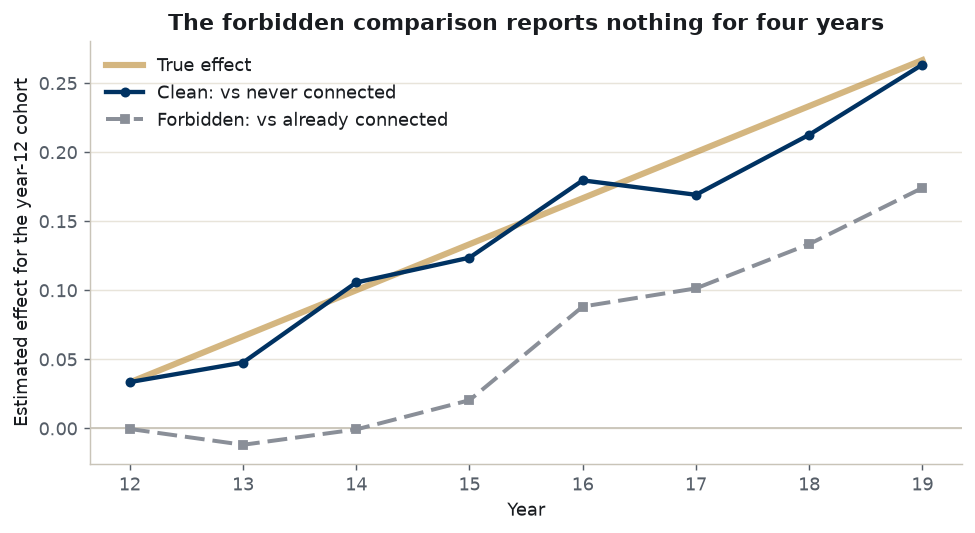

In [6]:
fig, ax = plt.subplots()
ax.axhline(0, color="#c9c4b8", lw=1)

ax.plot(comparison.index, comparison["True effect"], color=GOLD, lw=3.4,
        alpha=0.6, label="True effect", zorder=2)
ax.plot(comparison.index, comparison["vs never connected"], color=NAVY, lw=2.4,
        marker="o", ms=4.5, label="Clean: vs never connected", zorder=4)
ax.plot(comparison.index, comparison["vs connected in year 6"], color=GREY,
        lw=2.2, marker="s", ms=4.5, ls=(0, (5, 2)),
        label="Forbidden: vs already connected", zorder=3)

ax.set_title("The forbidden comparison reports nothing for four years")
ax.set_xlabel("Year")
ax.set_ylabel("Estimated effect for the year-12 cohort")
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.grid(axis="y")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


There it is. Between years 12 and 15 the true effect for the second wave climbs
from 0.03 to 0.13, the clean comparison follows it, and the forbidden comparison
sits at zero — dipping slightly negative along the way. Nothing is wrong with the
data. The control group is improving at nearly the same rate as the treatment
group, because it is still absorbing its own treatment, so the difference
between them registers almost nothing.

The single $\beta$ above is a weighted average that includes this comparison.
That is where the missing thirty percent went.


## Does the event study inherit the problem?

The usual next step is to replace the single indicator with one dummy per year
relative to connection, omitting $e=-1$ as the reference. Worth checking whether
this specification is damaged too, rather than assuming it either way.


In [7]:
LEADS, LAGS = 5, 7

es = panel.copy()
es["rel"] = np.where(es["cohort"] == 0, np.nan, es["year"] - es["cohort"])
es["rel_binned"] = es["rel"].clip(-LEADS, LAGS)

event_times = [e for e in range(-LEADS, LAGS + 1) if e != -1]
for e in event_times:
    es[f"D{e}"] = (es["rel_binned"] == e).astype(float)

twfe_es = twfe(es, [f"D{e}" for e in event_times])
twfe_es.index = event_times

truth_by_e = (
    panel.assign(rel=np.where(panel["cohort"] == 0, np.nan,
                              panel["year"] - panel["cohort"]))
         .dropna(subset=["rel"])
         .assign(rel=lambda d: d["rel"].clip(-LEADS, LAGS))
         .groupby("rel")["true_effect"].mean()
)
truth_by_e = truth_by_e - truth_by_e.loc[-1]

pd.DataFrame(
    {"True": truth_by_e.reindex(event_times).values,
     "TWFE event study": twfe_es.values},
    index=pd.Index(event_times, name="years since connection"),
).round(3).T


years since connection,-5,-4,-3,-2,0,1,2,3,4,5,6,7
True,0.000,0.000,0.000,0.000,0.033,0.067,0.100,0.133,0.167,0.200,0.233,0.292
TWFE event study,0.003,0.005,-0.002,0.002,0.032,0.066,0.105,0.125,0.176,0.193,0.229,0.287


## An estimator that fixes the comparison group

Rather than trusting the regression to pick comparisons, compute a separate
$ATT(g,t)$ for each cohort $g$ and year $t$ against units that are **not yet
treated** at $t$, always anchored to the last year before $g$ is connected
([Callaway and Sant'Anna,
2021](https://doi.org/10.1016/j.jeconom.2020.12.001)):

$$ATT(g,t) = \Big[\bar y^{\,g}_{t} - \bar y^{\,g}_{g-1}\Big]
           - \Big[\bar y^{\,\text{not yet}}_{t} - \bar y^{\,\text{not yet}}_{g-1}\Big]$$

then average those blocks by years since connection.


In [8]:
records = []
for g in [c for c in COHORTS if c != 0]:
    base = g - 1
    treated_units = cohort_of.index[cohort_of == g]
    for year in range(T):
        if year == base:
            continue
        # Controls: never connected, or connected strictly after this year.
        controls = cohort_of.index[(cohort_of == 0) | (cohort_of > max(year, g))]
        if len(controls) == 0:
            continue
        records.append({
            "cohort": g,
            "rel": year - g,
            "att": did(treated_units, controls, base, year),
            "n": len(treated_units),
        })

att_gt = pd.DataFrame(records)

not_yet_es = (
    att_gt[att_gt["rel"].between(-LEADS, LAGS)]
    .groupby("rel")
    .apply(lambda d: np.average(d["att"], weights=d["n"]), include_groups=False)
)

post = att_gt[att_gt["rel"] >= 0]
not_yet_att = np.average(post["att"], weights=post["n"])

print(f"Not-yet-treated ATT : {not_yet_att:.4f}   "
      f"({100 * (not_yet_att - true_att) / true_att:+.1f}% vs truth)")


Not-yet-treated ATT : 0.1888   (-1.1% vs truth)


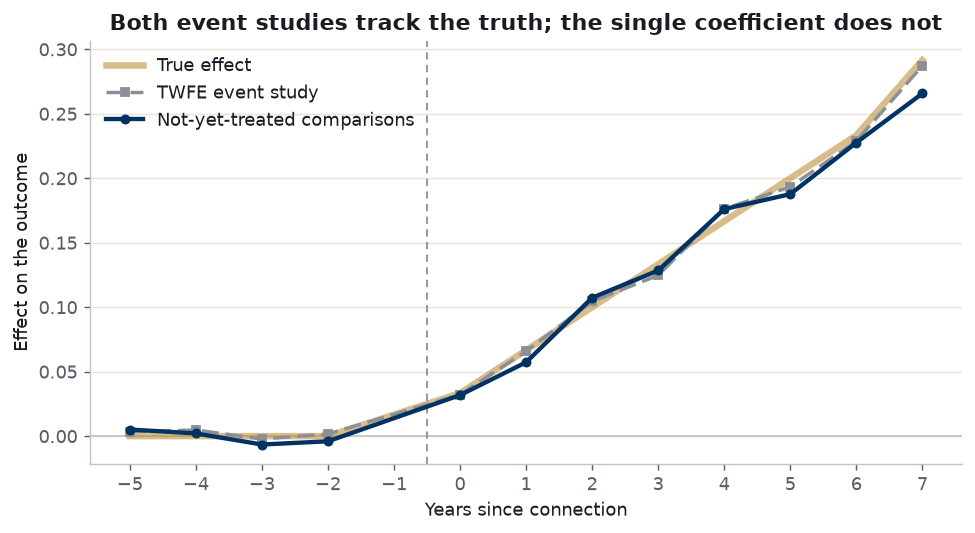

In [9]:
truth_line = truth_by_e.reindex(event_times)

fig, ax = plt.subplots()
ax.axhline(0, color="#c9c4b8", lw=1)
ax.axvline(-0.5, color=GREY, lw=1, ls=(0, (4, 3)))

ax.plot(truth_line.index, truth_line.values, color=GOLD, lw=3.6, alpha=0.55,
        label="True effect", zorder=2)
ax.plot(twfe_es.index, twfe_es.values, color=GREY, lw=1.9, marker="s", ms=4,
        ls=(0, (5, 2)), label="TWFE event study", zorder=3)
ax.plot(not_yet_es.index, not_yet_es.values, color=NAVY, lw=2.4, marker="o",
        ms=4.5, label="Not-yet-treated comparisons", zorder=4)

ax.set_title("Both event studies track the truth; the single coefficient does not")
ax.set_xlabel("Years since connection")
ax.set_ylabel("Effect on the outcome")
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.grid(axis="y")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [10]:
summary = pd.DataFrame({
    "Estimator": [
        "Truth (known by construction)",
        "TWFE, single coefficient",
        "Not-yet-treated comparisons",
    ],
    "ATT": [true_att, beta, not_yet_att],
})
summary["Gap"] = summary["ATT"] - true_att
summary["Gap (%)"] = 100 * summary["Gap"] / true_att
summary.round(4)


,Estimator,ATT,Gap,Gap (%)
0,Truth (known by construction),0.1909,0.0000,0.0000
1,"TWFE, single coefficient",0.1336,-0.0573,-30.0198
2,Not-yet-treated comparisons,0.1888,-0.0021,-1.1179


## What the never-connected districts are worth

One design choice did a lot of quiet work above: a third of the districts are
never connected, so a clean control group exists in every year. Drop them, and
the regression has nothing left to compare against but already-connected
districts.


In [11]:
no_never = panel[panel["cohort"] != 0].copy()
beta_no_never = twfe(no_never, ["treated"]).iloc[0]
true_no_never = no_never.query("treated == 1")["true_effect"].mean()

print(f"With never-connected    : {beta:.4f} vs truth {true_att:.4f}   "
      f"({100 * (beta - true_att) / true_att:+.1f}%)")
print(f"Without never-connected : {beta_no_never:.4f} vs truth {true_no_never:.4f}   "
      f"({100 * (beta_no_never - true_no_never) / true_no_never:+.1f}%)")


With never-connected    : 0.1336 vs truth 0.1909   (-30.0%)
Without never-connected : 0.0350 vs truth 0.1909   (-81.7%)


## What to take away

Read the numbers rather than the reputation of the method. In this design:

1. **The single coefficient is the problem, and the problem is large.** Thirty
   percent, with parallel trends holding exactly and both cohorts sharing the
   same effect profile. Under staggered adoption with an effect that takes time
   to arrive, it should not be reported on its own.

2. **The event study is not automatically damaged.** Here the saturated
   specification tracks the true path closely, before and after connection
   alike. That is worth knowing, because this literature is often read as
   condemning every fixed-effects specification. It condemns a particular
   comparison, not the whole family — and the way to find out which case you are
   in is to check, not to assume.

3. **Never-treated units are an asset, not leftovers.** They are the only group
   that is a valid control in every period. The last cell shows what happens to
   the same estimator once they are removed.

4. **Show the estimators side by side.** When a heterogeneity-robust estimator
   and the standard one agree, the reader learns the result is not an artefact of
   the method. When they disagree, the gap is itself a finding about how the
   effect evolves, and deserves a paragraph rather than a footnote.

The rollout of submarine cables across Sub-Saharan Africa is exactly this kind
of design — countries connected in different years, with an effect that
plausibly builds as complementary infrastructure catches up. That is why the
estimates in [Wired for Growth?](/research.html#wired-for-growth) come from a
heterogeneity-robust estimator rather than from a single fixed-effects
coefficient.

*Reproduce this page: download the notebook from the link at the top, or read the
source in the [site repository](https://github.com/ibgoni/ibgoni.github.io/tree/main/notebooks).
It needs only numpy, pandas and matplotlib.*
